# Exploratory Data Analysis (EDA)

## Import required libraries

In [28]:
import sys 
import os

sys.path.insert(0, os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_4/credit-risk-model/src'))

print('Path set. Python will now look in:', os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_4/credit-risk-model/src'))

Path set. Python will now look in: C:\Users\dagic\OneDrive\Documents\KAIM\Week_4\credit-risk-model\src


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import data_loader as ld
import plots as pl

### Import Dataset

In [30]:
df = ld.load_data('../data/raw/data.csv')

Dataset loaded successfully.
Shape: (95662, 16)


## Overview of Dataset

In [31]:
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

In [33]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [34]:
df.dtypes

TransactionId               str
BatchId                     str
AccountId                   str
SubscriptionId              str
CustomerId                  str
CurrencyCode                str
CountryCode               int64
ProviderId                  str
ProductId                   str
ProductCategory             str
ChannelId                   str
Amount                  float64
Value                     int64
TransactionStartTime        str
PricingStrategy           int64
FraudResult               int64
dtype: object

## Distribution of Numerical Features

In [35]:
num_columns = df.select_dtypes(include='number')

In [36]:
num_columns.head()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
0,256,1000.0,1000,2,0
1,256,-20.0,20,2,0
2,256,500.0,500,2,0
3,256,20000.0,21800,2,0
4,256,-644.0,644,2,0


In [37]:
num_columns.dtypes

CountryCode          int64
Amount             float64
Value                int64
PricingStrategy      int64
FraudResult          int64
dtype: object

## Distribution of Fraud Result

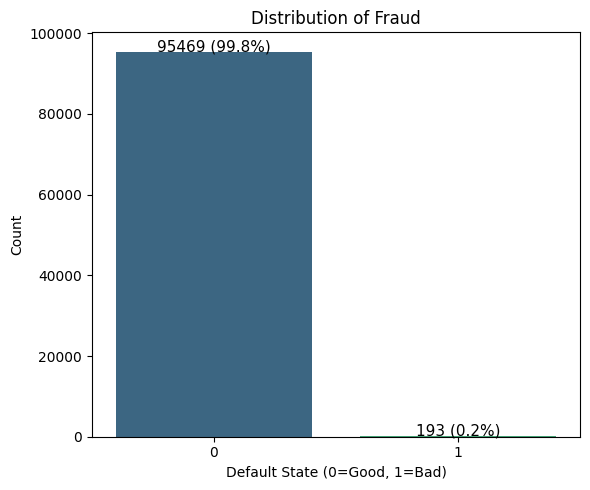

In [38]:
# Good (0) vs Bad (1) credit risk
default_counts = df['FraudResult'].value_counts()
default_rates = df['FraudResult'].value_counts(normalize=True) 

fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(x=default_counts.index, y=default_counts.values, hue=default_counts.index, palette='viridis', legend=False, ax=ax)
ax.set_title('Distribution of Fraud')
ax.set_xlabel('Default State (0=Good, 1=Bad)')
ax.set_ylabel('Count')

for i, count in enumerate(default_counts):
    pct = default_rates.iloc[i] * 100
    ax.annotate(f"{count} ({pct:.1f}%)", xy=(i, count + 15), ha='center', fontsize=11)
plt.tight_layout()
plt.show()


### Interpretation:

    -   The 98% of the data is free of fraudulent activities.

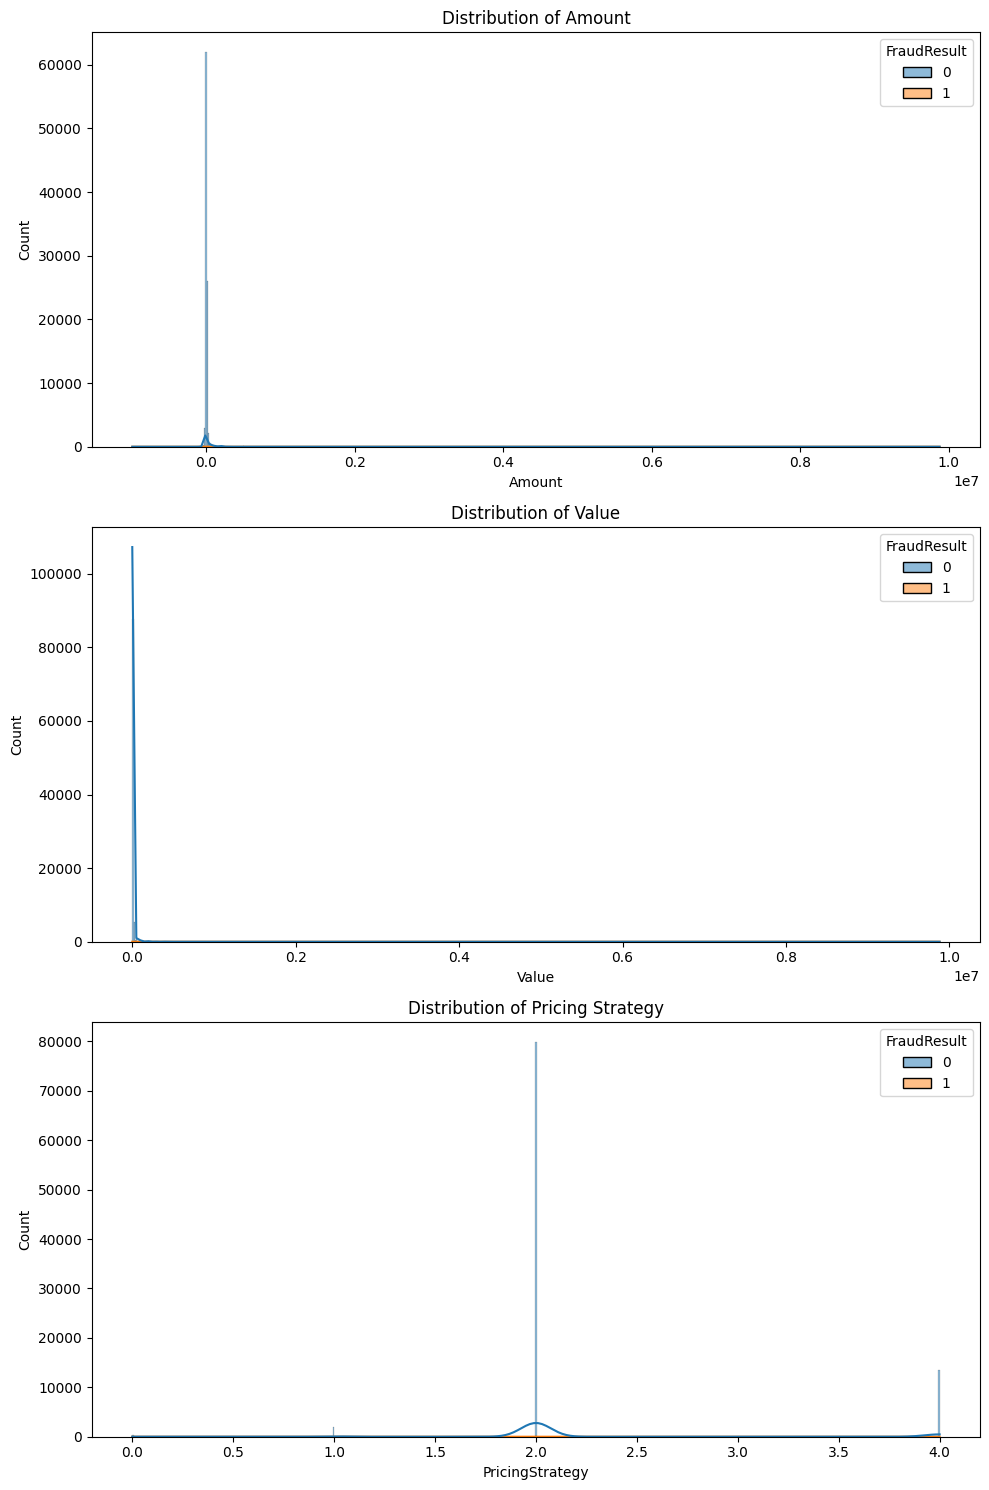

In [39]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Duration Months
sns.histplot(data=df, x='Amount', hue='FraudResult', kde=True, multiple='stack', palette='tab10', ax=axes[0])
axes[0].set_title('Distribution of Amount')

# Credit Amount
sns.histplot(data=df, x='Value', hue='FraudResult', kde=True, multiple='stack', palette='tab10', ax=axes[1])
axes[1].set_title('Distribution of Value')

# Age
sns.histplot(data=df, x='PricingStrategy', hue='FraudResult', kde=True, multiple='stack', palette='tab10', ax=axes[2])
axes[2].set_title('Distribution of Pricing Strategy')

plt.tight_layout()
plt.show()

### Interpretation:

    -   The data is extremely right skiwwed for Distribution of Amount and Value
    

### Logscaled Numerical Columns

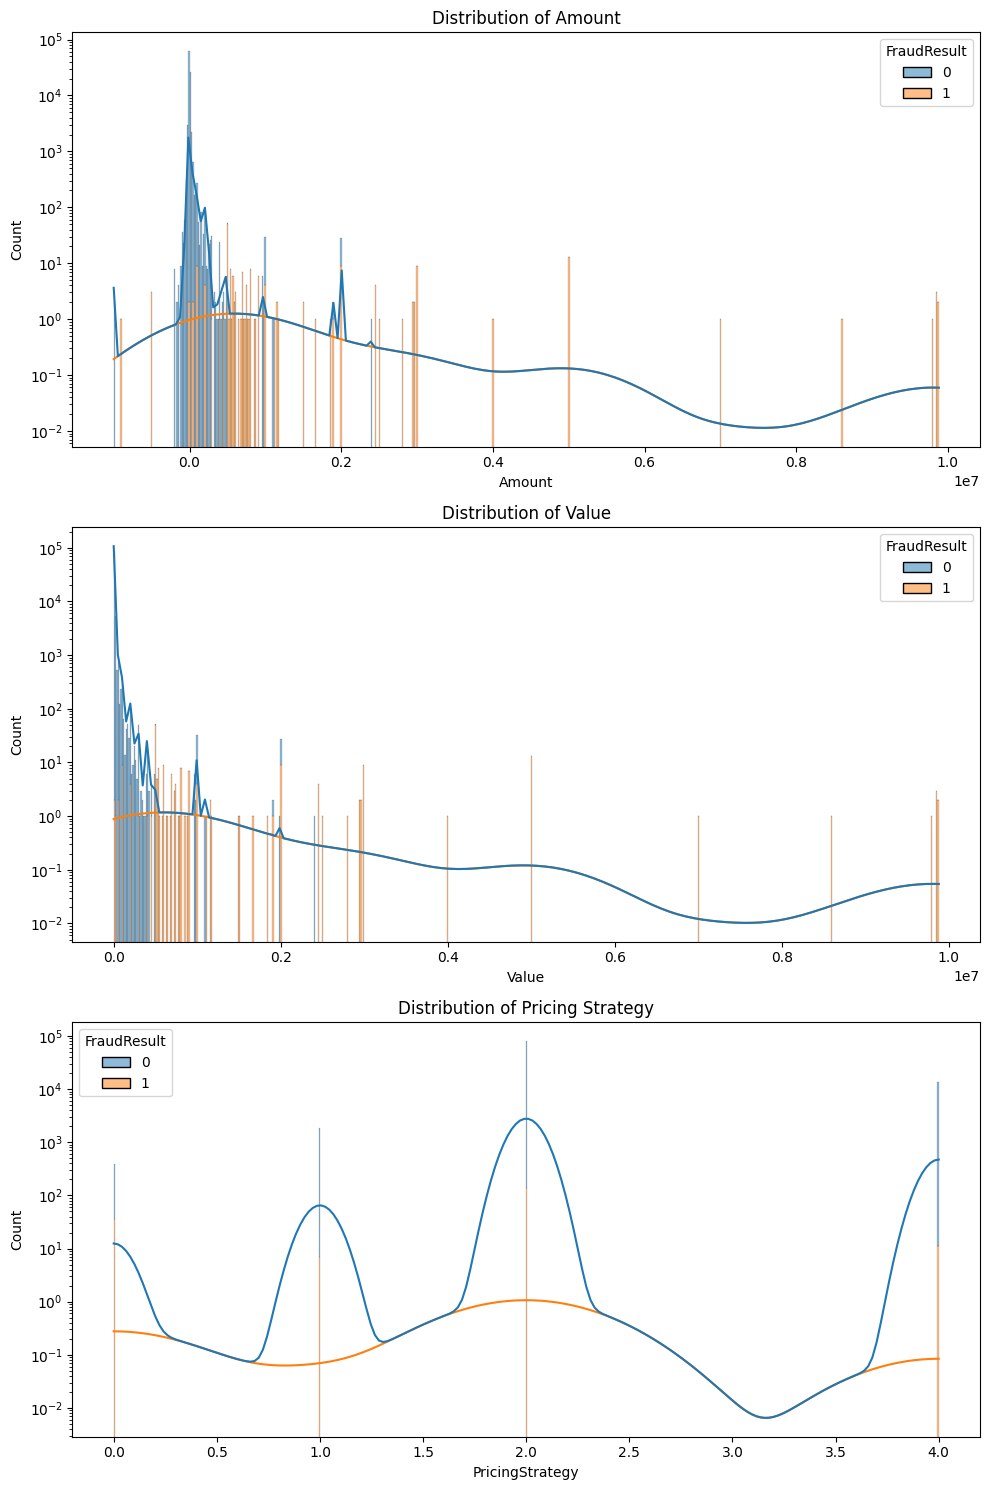

In [40]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Duration Months
sns.histplot(data=df, x='Amount', hue='FraudResult', kde=True, multiple='stack', palette='tab10', ax=axes[0])
axes[0].set_title('Distribution of Amount')
axes[0].set_yscale('log')
# Credit Amount
sns.histplot(data=df, x='Value', hue='FraudResult', kde=True, multiple='stack', palette='tab10', ax=axes[1])
axes[1].set_title('Distribution of Value')
axes[1].set_yscale('log')
# Age
sns.histplot(data=df, x='PricingStrategy', hue='FraudResult', kde=True, multiple='stack', palette='tab10', ax=axes[2])
axes[2].set_title('Distribution of Pricing Strategy')
axes[2].set_yscale('log')
plt.tight_layout()
plt.show()

### Interpretation:

    -   Amount and Value is right skiwwed. Also, the fraud activities are skiwwed to the right.

    -   While Strategy 2 has way more total transactions, the ratio of the fraudResult 1 to 0 at Strategy 4 is visibly higher. Strategy 4 has a higher density of fraud cases relative to its overall volume.

## Correlation between Numerical Columns

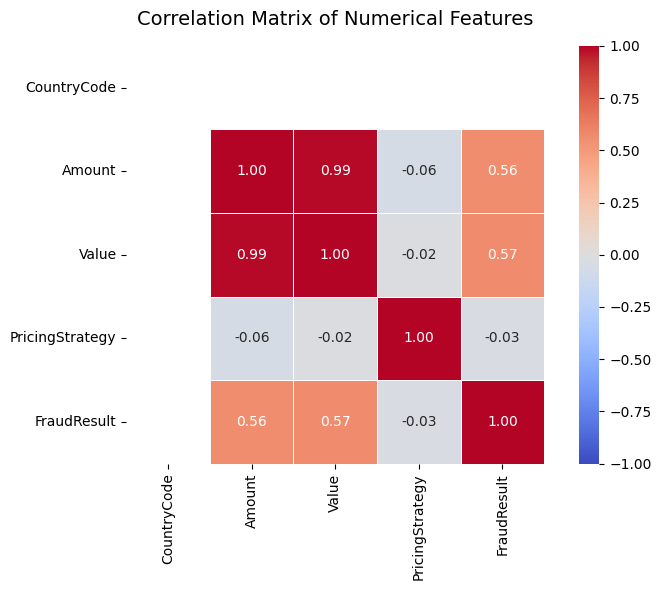

In [43]:
pl.plot_corr(num_columns)

### Interpretation

    -   FraudResult is highly related to Amount and Value than others.

## Categorical Columns

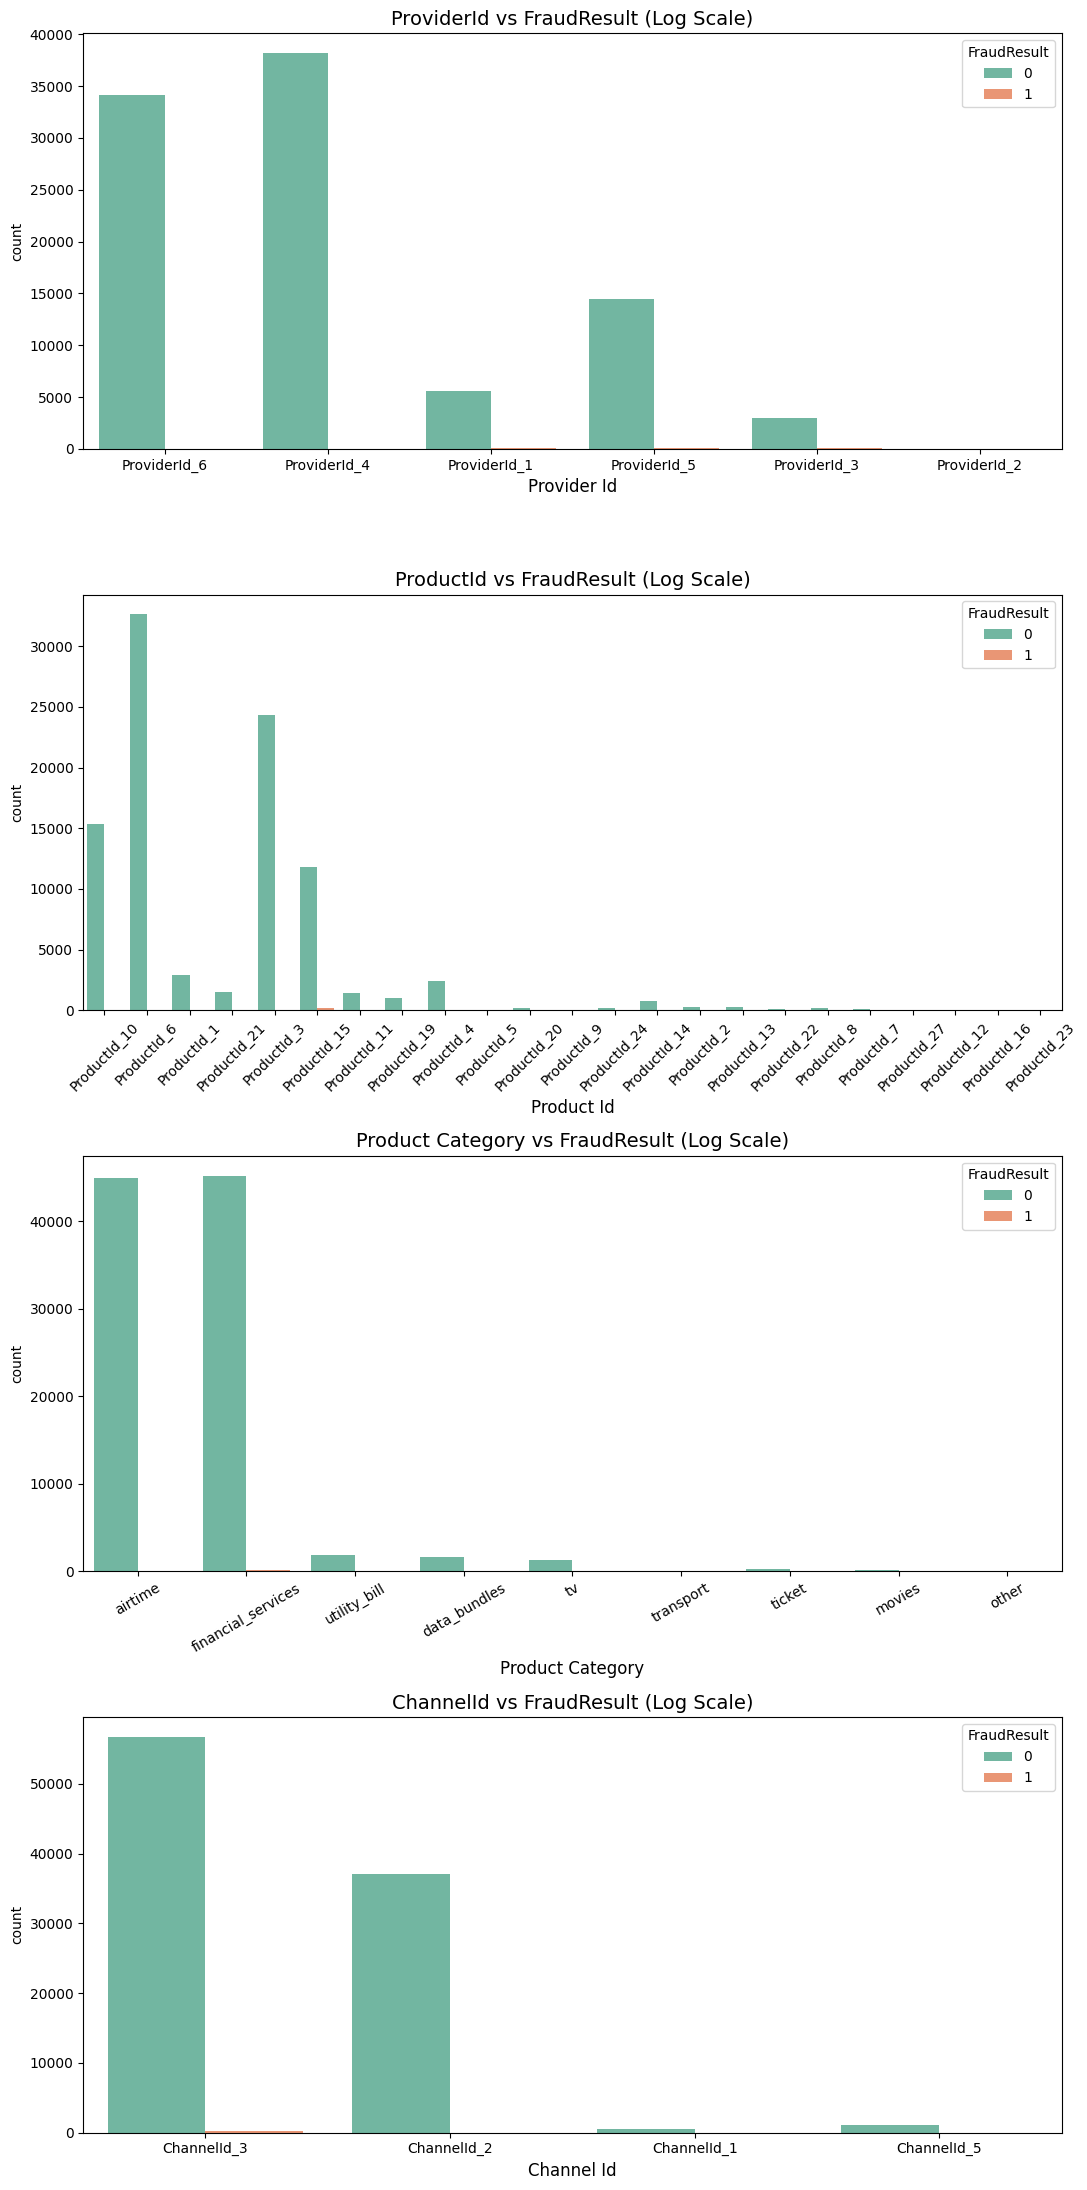

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 4x1 grid cleanly
fig, axes = plt.subplots(4, 1, figsize=(11, 22))

# 1. ProviderId (Index 0)
sns.countplot(data=df, x='ProviderId', hue='FraudResult', palette='Set2', ax=axes[0])
axes[0].set_title('ProviderId vs FraudResult (Log Scale)', fontsize=14)
axes[0].set_xlabel('Provider Id', fontsize=12)

# 2. ProductId (Index 1)
sns.countplot(data=df, x='ProductId', hue='FraudResult', palette='Set2', ax=axes[1])
axes[1].set_title('ProductId vs FraudResult (Log Scale)', fontsize=14)
axes[1].set_xlabel('Product Id', fontsize=12)
axes[1].tick_params(axis='x', rotation=45) # Rotates IDs so they don't overlap

# 3. ProductCategory (Index 2 - FIXED)
sns.countplot(data=df, x='ProductCategory', hue='FraudResult', palette='Set2', ax=axes[2])
axes[2].set_title('Product Category vs FraudResult (Log Scale)', fontsize=14)
axes[2].set_xlabel('Product Category', fontsize=12)
axes[2].tick_params(axis='x', rotation=30)

# 4. ChannelId (Index 3 - FIXED)
sns.countplot(data=df, x='ChannelId', hue='FraudResult', palette='Set2', ax=axes[3])
axes[3].set_title('ChannelId vs FraudResult (Log Scale)', fontsize=14)
axes[3].set_xlabel('Channel Id', fontsize=12)

plt.tight_layout()
plt.show()

Interpretation:

    -    The plots are too skewwed to interprete

### Logscaled Categorical Columns

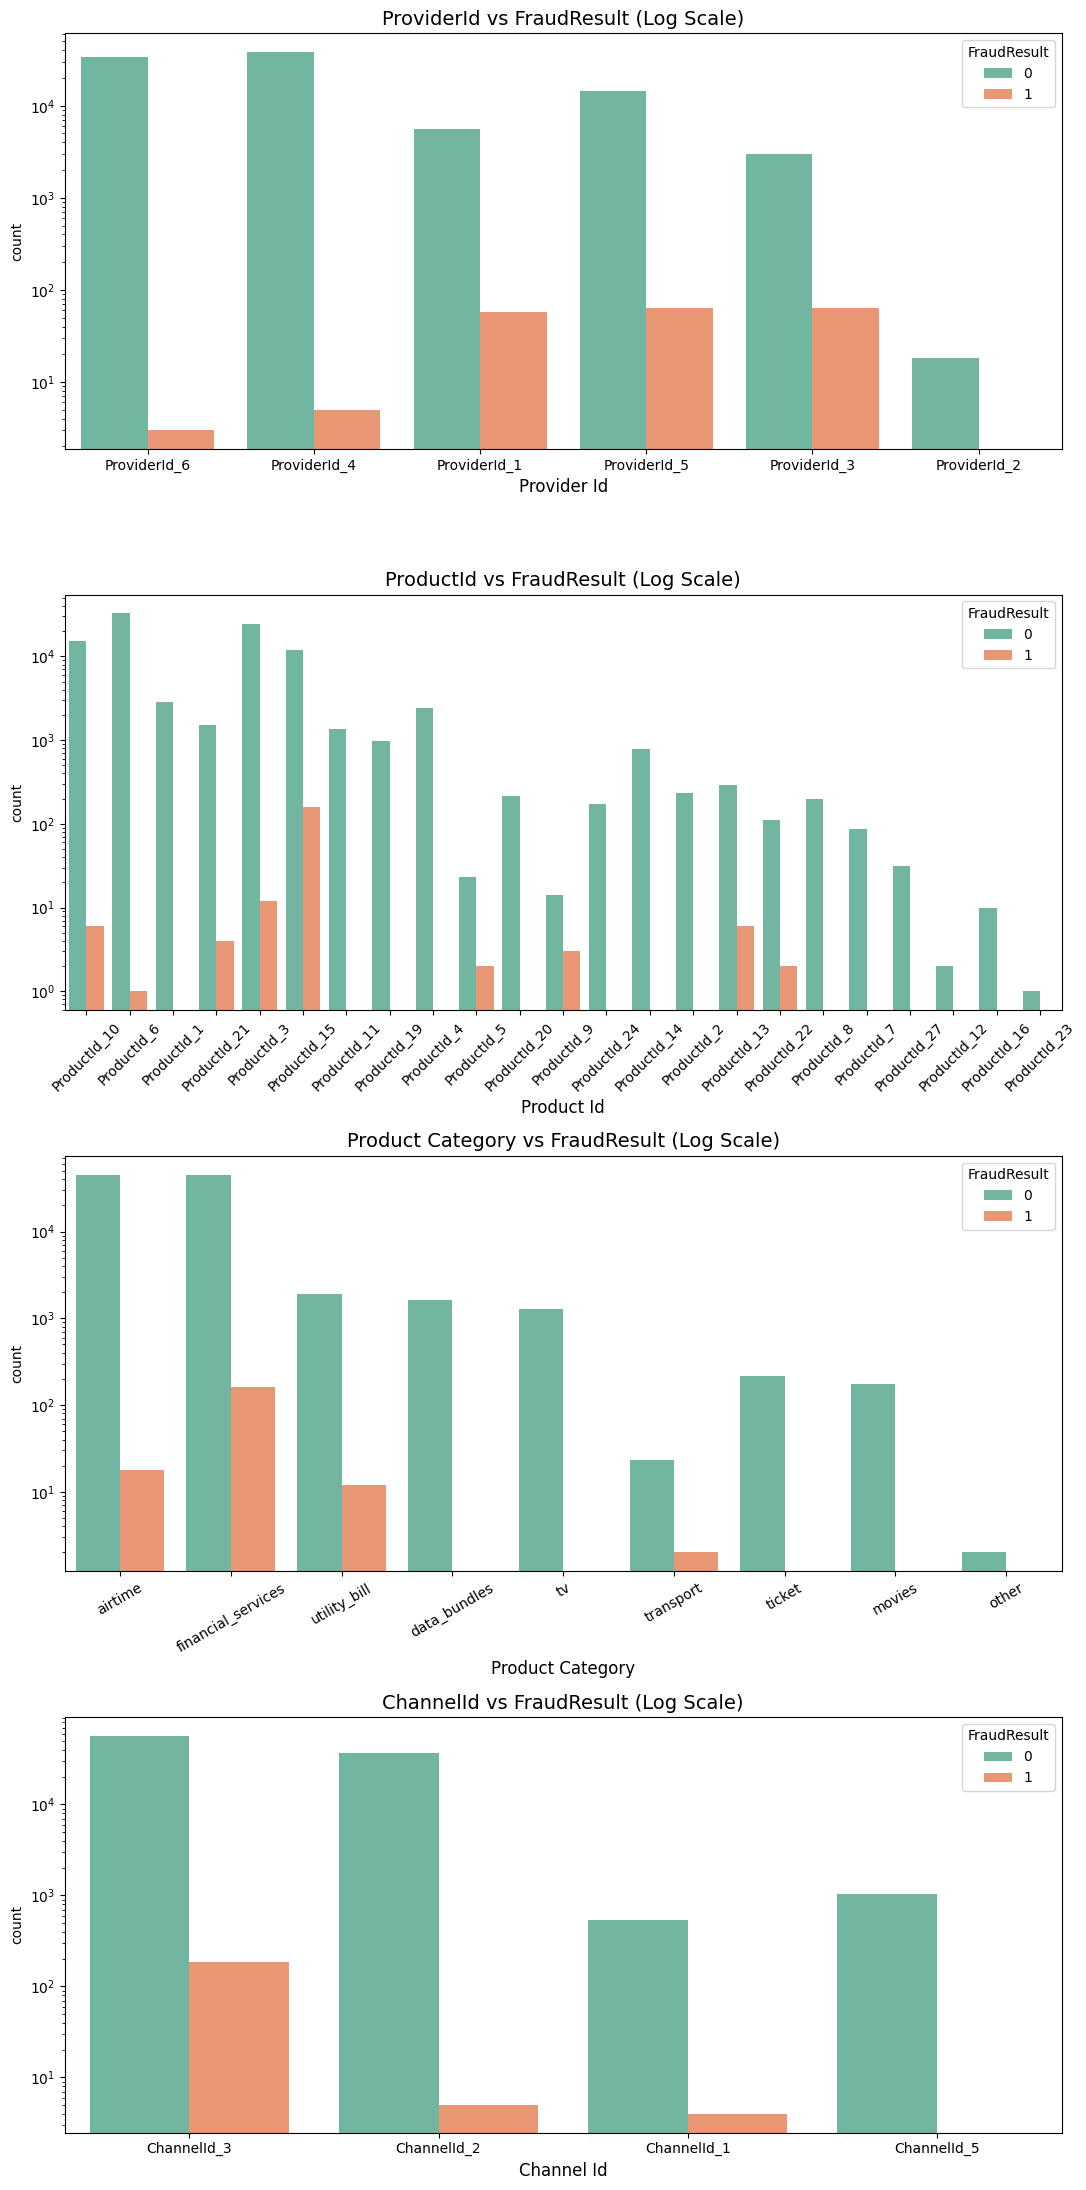

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 4x1 grid cleanly
fig, axes = plt.subplots(4, 1, figsize=(11, 22))

# 1. ProviderId (Index 0)
sns.countplot(data=df, x='ProviderId', hue='FraudResult', palette='Set2', ax=axes[0])
axes[0].set_title('ProviderId vs FraudResult (Log Scale)', fontsize=14)
axes[0].set_xlabel('Provider Id', fontsize=12)
axes[0].set_yscale('log')  # Makes fraud bars visible

# 2. ProductId (Index 1)
sns.countplot(data=df, x='ProductId', hue='FraudResult', palette='Set2', ax=axes[1])
axes[1].set_title('ProductId vs FraudResult (Log Scale)', fontsize=14)
axes[1].set_xlabel('Product Id', fontsize=12)
axes[1].set_yscale('log')
axes[1].tick_params(axis='x', rotation=45) # Rotates IDs so they don't overlap

# 3. ProductCategory (Index 2 - FIXED)
sns.countplot(data=df, x='ProductCategory', hue='FraudResult', palette='Set2', ax=axes[2])
axes[2].set_title('Product Category vs FraudResult (Log Scale)', fontsize=14)
axes[2].set_xlabel('Product Category', fontsize=12)
axes[2].set_yscale('log')
axes[2].tick_params(axis='x', rotation=30)

# 4. ChannelId (Index 3 - FIXED)
sns.countplot(data=df, x='ChannelId', hue='FraudResult', palette='Set2', ax=axes[3])
axes[3].set_title('ChannelId vs FraudResult (Log Scale)', fontsize=14)
axes[3].set_xlabel('Channel Id', fontsize=12)
axes[3].set_yscale('log')

plt.tight_layout()
plt.show()

### Interpretation:

    -   Provider 1, 5 and 3: Even though they process way less traffic overall, the proportion of fraud on these providers is incredibly high. 

    -   Product ID 15 stands out with a very noticeable fraud spike.

    -   financial_services has an orange fraud bar that completely dwarfs every other category.

    -   ChannelId_3 handles the most traffic, but it also carries almost all of the fraud in the entire dataset.

## Outlier Capping

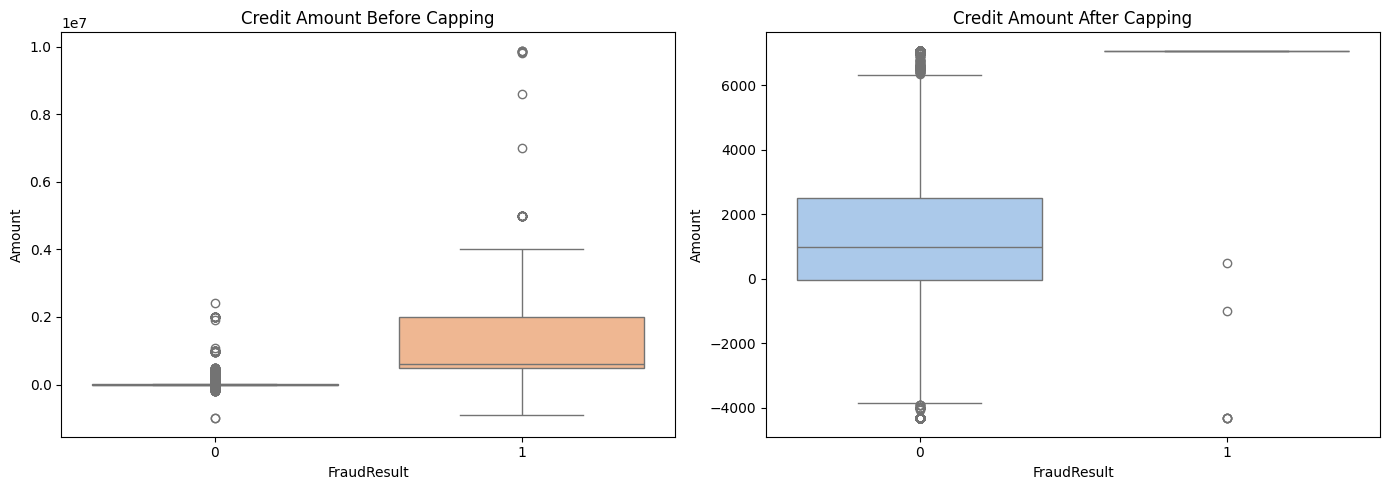

In [44]:
from data_processing import cap_outliers

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='FraudResult', y='Amount', hue='FraudResult', palette='pastel', legend=False, ax=axes[0])
axes[0].set_title('Credit Amount Before Capping')

# Cap outliers in numeric columns before plotting the post-capping distribution
df_capped = cap_outliers(df, cols=['Amount', 'Value'])

sns.boxplot(data=df_capped, x='FraudResult', y='Amount', hue='FraudResult', palette='pastel', legend=False, ax=axes[1])
axes[1].set_title('Credit Amount After Capping')

plt.tight_layout()
plt.show()

### Interpretation:

    -   fraud point (0) is crippled. This happens because the Y-axis has to stretch all the way up to 1.0 10^7 (10 million) to accommodate a few massive, multi-million dollar fraud points (1).

    -   On the second figure, fraud point (0) is revealed because fraud point(1) is transformed to the maximum around 7000.